In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

Verilerin yüklenmesi

In [2]:
df = pd.read_csv('missense_mutations.csv')
df_filtered = df[df['ClinSigSimple'].isin([0, 1])].copy()
df_filtered

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
1,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
2,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
3,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
4,24384,single nucleotide variant,NM_000059.4(BRCA2):c.7529T>C (p.Leu2510Pro),675,BRCA2,HGNC:1101,Pathogenic/Likely pathogenic,1,"Jul 09, 2024",80358979,...,C,-,-,-,-,-,-,SCV000567107|SCV000607817|SCV001478276|SCV0015...,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11229,4185255,single nucleotide variant,NM_000059.4(BRCA2):c.8754G>C (p.Glu2918Asp),675,BRCA2,HGNC:1101,Likely pathogenic,1,"Jun 12, 2025",-1,...,C,-,-,-,-,-,-,SCV006298678,-,-
11230,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11231,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11232,4391609,single nucleotide variant,NM_007294.4(BRCA1):c.298G>C (p.Glu100Gln),672,BRCA1,HGNC:1100,Uncertain significance,0,"Jul 31, 2025",-1,...,G,-,-,-,-,-,-,SCV006554521,-,-


In [3]:
print(df_filtered['ClinSigSimple'].value_counts(normalize=True))

ClinSigSimple
0    0.907679
1    0.092321
Name: proportion, dtype: float64


In [4]:
df_majority = df_filtered[df_filtered.ClinSigSimple == 0] # Benign
df_minority = df_filtered[df_filtered.ClinSigSimple == 1] # Pathogenic

In [5]:
df_majority_downsampled = resample(df_majority, 
                                 replace=False,    
                                 n_samples=len(df_minority),
                                 random_state=42)

In [6]:
df_balanced = pd.concat([df_majority_downsampled, df_minority])
print(f"Eşitlenmiş Dağılım: {df_balanced['ClinSigSimple'].value_counts().to_dict()}")

Eşitlenmiş Dağılım: {0: 832, 1: 832}


Özelliklerin çıkartılması (Kullanılacak sütunların belirlenmesi)

In [7]:
features = ['GeneSymbol', 'Chromosome', 'Start', 'Stop', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']
X = df_balanced[features].copy()
y = df_balanced['ClinSigSimple'].values

Kategorik verilerin sayısallaştırılması

In [8]:
le = LabelEncoder()
for col in ['GeneSymbol', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']:
    X[col] = le.fit_transform(X[col].astype(str))

Ölçeklendirme işlemi

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Verinin giriş boyutunun belirlenmesi

In [10]:
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

Modelin eğitim / test olarak ayrılması

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42, stratify=y)

Modelin oluşturulması

In [12]:
model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # İkili sınıflandırma çıktısı
])

C:\Users\emirh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Modelin eğitilmesi

In [14]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6245 - loss: 0.6812 - val_accuracy: 0.6866 - val_loss: 0.6246
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6147 - loss: 0.6608 - val_accuracy: 0.6866 - val_loss: 0.5990
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6063 - loss: 0.6601 - val_accuracy: 0.6866 - val_loss: 0.5884
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6411 - loss: 0.6461 - val_accuracy: 0.7313 - val_loss: 0.5897
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6430 - loss: 0.6331 - val_accuracy: 0.7313 - val_loss: 0.5855
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6209 - loss: 0.6493 - val_accuracy: 0.7313 - val_loss: 0.5807
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6161 - loss: 0.6460 - val_accuracy: 0.7388 - val_loss: 0.5788
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6199 - loss: 0.6561 - val_accuracy: 0.7090 - val_loss

Modelin değerlendirilmesi

In [15]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.68      0.65       167
           1       0.64      0.58      0.61       166

    accuracy                           0.63       333
   macro avg       0.63      0.63      0.63       333
weighted avg       0.63      0.63      0.63       333



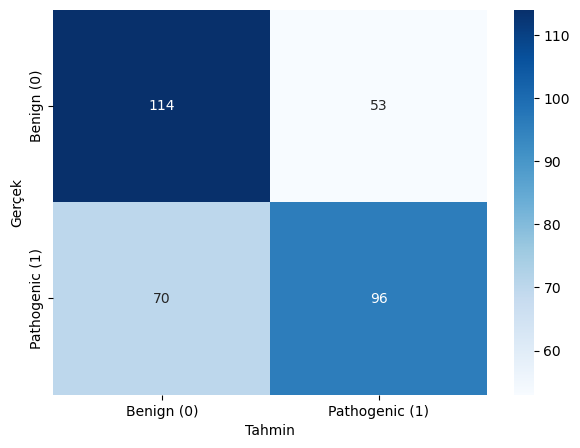

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Pathogenic (1)'], 
            yticklabels=['Benign (0)', 'Pathogenic (1)'])
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.show()

In [18]:
acc = accuracy_score(y_test, y_pred)
acc

0.6306306306306306

## Optuna Kullanımı

In [19]:
def objective(trial):
    # 1. Hiperparametreler
    n_layers = trial.suggest_int('n_layers', 1, 3) 
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    model = Sequential()
    
    # 2. Dinamik GRU Mimarisi
    for i in range(n_layers):
        units = trial.suggest_int(f'gru_units_l{i}', 16, 128, step=16)
        
        is_last_gru = (i == n_layers - 1)
        
        if i == 0:
            # Giriş katmanı
            model.add(GRU(units, return_sequences=not is_last_gru, 
                          input_shape=(X_train.shape[1], X_train.shape[2])))
        else:
            model.add(GRU(units, return_sequences=not is_last_gru))
        
        model.add(Dropout(trial.suggest_float(f'dropout_l{i}', 0.1, 0.4)))
    
    # Çıkış Katmanı 
    model.add(Dense(1, activation='sigmoid'))

    # 3. Derleme
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # 4. Eğitim 
    history = model.fit(
        X_train, y_train,
        epochs=15, 
        batch_size=batch_size,
        validation_split=0.2, 
        verbose=0
    )

    # 5. Skor
    val_acc = history.history['val_accuracy'][-1]
    return val_acc

In [20]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2026-03-22 12:08:21,970] A new study created in memory with name: no-name-78788d5f-9acf-460d-a5ed-934c7892d9e0
C:\Users\emirh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2026-03-22 12:08:29,782] Trial 0 finished with value: 0.6779026389122009 and parameters: {'n_layers': 3, 'learning_rate': 0.00035514020000991026, 'batch_size': 16, 'gru_units_l0': 64, 'dropout_l0': 0.15491584821667803, 'gru_units_l1': 80, 'dropout_l1': 0.34293036214810746, 'gru_units_l2': 80, 'dropout_l2': 0.1598370653233579}. Best is trial 0 with value: 0.6779026389122009.
[I 2026-03-22 12:08:38,297] Trial 1 finished with value: 0.6928839087486267 and parameters: {'n_layers': 3, 'learning_rate': 0.002494586503928793, 'batch_size': 16, 'gru_units_l0': 112, 'dropout_l0': 0.204047778835790

In [21]:
print(f"En İyi GRU Skoru: {study.best_value:.4f}")
print("En İyi Parametreler:", study.best_params)

En İyi GRU Skoru: 0.7041
En İyi Parametreler: {'n_layers': 1, 'learning_rate': 0.003477643351515019, 'batch_size': 64, 'gru_units_l0': 32, 'dropout_l0': 0.11886268380021422}
